This notebook can be used to preprocess confidence scores by various systems (uncertainty quantifiers) into "normalised" confidences. For this we need human annotation.

The normalised confidences can be used in place of the raw scores for example to analyse whether annotation errors (say, by automated judges) distribute in relation to confidence scores.

In [ ]:
# !pip install numpyro
# !pip install jax

In `confdl` we have some useful data loaders. 

In [1]:
import numpy as np
import json
from collections import OrderedDict, defaultdict

from confdl import reformat_json, Vocabulary, Dataset

## Load and preprocess

In [2]:
# experiment = 'ambig_qa_multiple_qas_llama-3b-instruct_100_0'
experiment = 'trivia_qa_llama-8b-instruct_incl_human_judges'
input_file = f"data/{experiment}.json"
keep = {
    # Only trustworthy judges
    'human_judge1', 
    'human_judge2', # sometimes it is there, if there we keep it
    # All uncertainty quantifiers
    'log_likelihood_seq', 
    'log_likelihood_token', 
    'entropy', 
    'semantic_entropy', 
    'semantic_confidence', 
    'verbalised_confidence', 
    'p_true'
}
jrows, srows = reformat_json(
    input_file,
    # no need to reverse anything, this model learns to reverse via the slope coefficient
    # it's neater that way
    # reverse={'entropy', 'semantic_entropy'},
    keep=keep
)

In [3]:
ds = Dataset(system_rows=srows, judge_rows=jrows, standardize=True)
ds.I.shape, ds.S.shape, ds.X.shape, ds.J.shape, ds.Y.shape

((1400,), (1400,), (1400,), (1400,), (1400,))

In [4]:
ds.sys2id.objects

['entropy',
 'semantic_entropy',
 'semantic_confidence',
 'log_likelihood_seq',
 'log_likelihood_token',
 'p_true',
 'verbalised_confidence']

In [5]:
ds.judge2id.objects

['human_judge1', 'human_judge2']

In [6]:
np.array([j_name.startswith('human') for j_name in ds.judge2id.objects])

array([ True,  True])

In [7]:
len(ds.item2id), len(ds.sys2id), len(ds.judge2id)

(100, 7, 2)

In [8]:
ds.X.mean(), ds.X.std()

(np.float64(-6.344131569286608e-17), np.float64(0.5))

# BDA

* $n$ indexes one of $N$ observations
* $i_n$ is the item id (i.e., a prompt-response pair in the dataset)
* $s_n$ is the system id
* $x_n$ is the confidence score assigned by system
* $j_n$ is the judge  id
* $y_n$ is the label produced by the judge/annotator

Confidence scores are not all between 0 and 1 and are not comparable across items, so we learn a latent mapping:

$z_{n} = b_{s_n} + w_{s_n}  x_n + (\mu + c_{j_n}) + (\rho +  m_{j_n})  x_{n}$

where
* $b, w$ are parameters of the systems
* $\mu$ and $\rho$ are parameters of the oracle 
* $c, m$ are parameters of the judges; if the judge is an oracle they are ommited -- this means that judges who are not oracle are treated as shifted (intercept and slope) oracles as if the Oracle was the prior of the judge (neat trick)

And then 

$y_n|x_n \sim \operatorname{Bernoulli}(\operatorname{sigmoid}(z_n))$


This is what the tall representation looks like:

```
Observation Item S      A     X     Y
1           1    verbc  h1    0.2   1
2           1    verbc  gpt   0.2   1
3           2    SE     h1    -1.2  0
4           2    SE     gpt   -1.2  1
```



In [9]:
import json
import numpy as np
import jax
import jax.numpy as jnp
import jax.scipy.special as jsp 
import jax.nn as jnn
import numpyro
import numpyro.distributions as dist
import matplotlib.pyplot as plt

In [10]:
def model(y, x, mask, system, judge, oracle, num_items, num_judges, num_systems):
    """
    N is number of observations.
    
    y: (N,) labels
    x: (N,) confidence scores 
    mask: (N,) use it to mask the likelihood function (eg, to handle missing data)
    system: (N,) system ids
    judge: (N,) judge ids
    oracle: (J,) one flag per judge, use True if Oracle
    num_items: number of prompt-response pairs in the dataset
    num_judges: number of judges
    num_systems: number of systems (uncertainty quantifiers)
    """

    b0 = numpyro.sample("b0", dist.Normal(0., 2.))
    w0 = numpyro.sample("w0", dist.Normal(0., 2.))
    
    with numpyro.plate("systems", num_systems):
        bs = numpyro.sample("bs", dist.Normal(0., 2.))
        ws = numpyro.sample("ws", dist.Normal(0., 2.))
    
    with numpyro.plate("judges", num_judges):        
        bj = numpyro.sample("bj", dist.Normal(0., 2.))
        wj = numpyro.sample("wj", dist.Normal(0., 2.))

        bj = jnp.where(oracle, b0, b0 + bj)
        wj = jnp.where(oracle, w0, w0 + wj)

    # with numpyro.plate("j_level", num_judges, dim=-2):        
    #     with numpyro.plate("s_level", num_systems, dim=-1):
    #         w = numpyro.sample("w", dist.Normal(0., 2.))

    #with numpyro.plate("items", num_items):
        # Probability that z_i is True
        # [N]        
    # z = numpyro.deterministic("z", b0 + bj[judge] + bs[system] + w[judge, system] * x)
    #z = numpyro.deterministic("z", b0 + bj[judge] + bs[system] + w[system] * x)

    z0 = numpyro.deterministic("z0", b0 + w0 * x)
    zs = numpyro.deterministic("zs", bs[system] + ws[system] * x)
    zj = numpyro.deterministic("zj", bs[judge] + wj[judge] * x)
    z = numpyro.deterministic("z", zs + zj)

    theta = numpyro.deterministic("theta", jax.nn.sigmoid(z))
    
    numpyro.sample(
        "obs",
        dist.Bernoulli(theta).mask(mask),
        obs=y
    )

# Inference

In [11]:
from numpyro.infer import MCMC, NUTS
from jax import random

NUM_CHAINS = 1
numpyro.set_host_device_count(NUM_CHAINS)

In [12]:
kernel = NUTS(model)

mcmc = MCMC(
    kernel,
    num_warmup=1000,
    num_samples=2000,
    num_chains=2
)

/var/folders/5n/kqrxk4_d27342m7xqqjhg42c0000gn/T/ipykernel_58873/1101456103.py:3: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(


In [13]:
rng_key = random.PRNGKey(0)

mcmc.run(
    rng_key,
    y=ds.Y,
    x=ds.X,
    mask=np.ones_like(ds.Y),
    judge=ds.J,
    system=ds.S,
    oracle=np.array([j_name.startswith('human_') for j_name in ds.judge2id.objects]),
    num_items=len(ds.item2id),
    num_judges=len(ds.judge2id),
    num_systems=len(ds.sys2id),    
)

sample: 100%|█| 3000/3000 [00:05<00:00, 542.24it/s, 31 steps of size 1.81e-01. acc. pro
sample: 100%|█| 3000/3000 [00:04<00:00, 617.48it/s, 15 steps of size 1.88e-01. acc. pro


Ideally: `r_hat` is close to 1 and we have 0 divergences.

In [14]:
mcmc.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
        b0     -0.06      2.01     -0.10     -3.16      3.41   4154.28      1.00
     bj[0]     -0.01      2.07     -0.03     -3.44      3.27   4389.99      1.00
     bj[1]     -0.02      1.98     -0.03     -3.08      3.39   4634.94      1.00
     bs[0]      0.59      0.10      0.59      0.42      0.75   2842.20      1.00
     bs[1]      0.69      0.10      0.69      0.53      0.85   3071.52      1.00
     bs[2]      0.37      0.19      0.37      0.06      0.69   3377.59      1.00
     bs[3]      0.38      0.20      0.38      0.06      0.71   3217.89      1.00
     bs[4]      0.45      0.19      0.45      0.12      0.76   3067.70      1.00
     bs[5]      0.42      0.19      0.42      0.10      0.74   3596.46      1.00
     bs[6]     -0.37      0.36     -0.37     -1.00      0.17   3032.47      1.00
        w0      1.25      0.76      1.24     -0.01      2.52   1188.43      1.00
     wj[0]      0.01      1

In [15]:
import arviz as az 

idata = az.from_numpyro(
    mcmc,
    dims={
        'b0': [],
        'bj': ['judges'],
        'bs': ['systems'],
        'w0': [],
        'wj': ['judges'],
        'ws': ['systems'],
        'theta': ['items'],
        'z': ['items'],
        'z0': ['items'],
        'zj': ['items'],
        'zs': ['items'],        
    },
    coords={
        "judges": ds.judge2id, 
        "systems": ds.sys2id, 
        "items": np.arange(len(ds.I)),
    }   
)

In [26]:
import matplotlib as mpl
mpl.rcParams["axes.grid"] = True
mpl.rcParams["axes.grid.axis"] = "x"   # only vertical lines
mpl.rcParams["grid.linestyle"] = "--"
mpl.rcParams["grid.alpha"] = 0.3

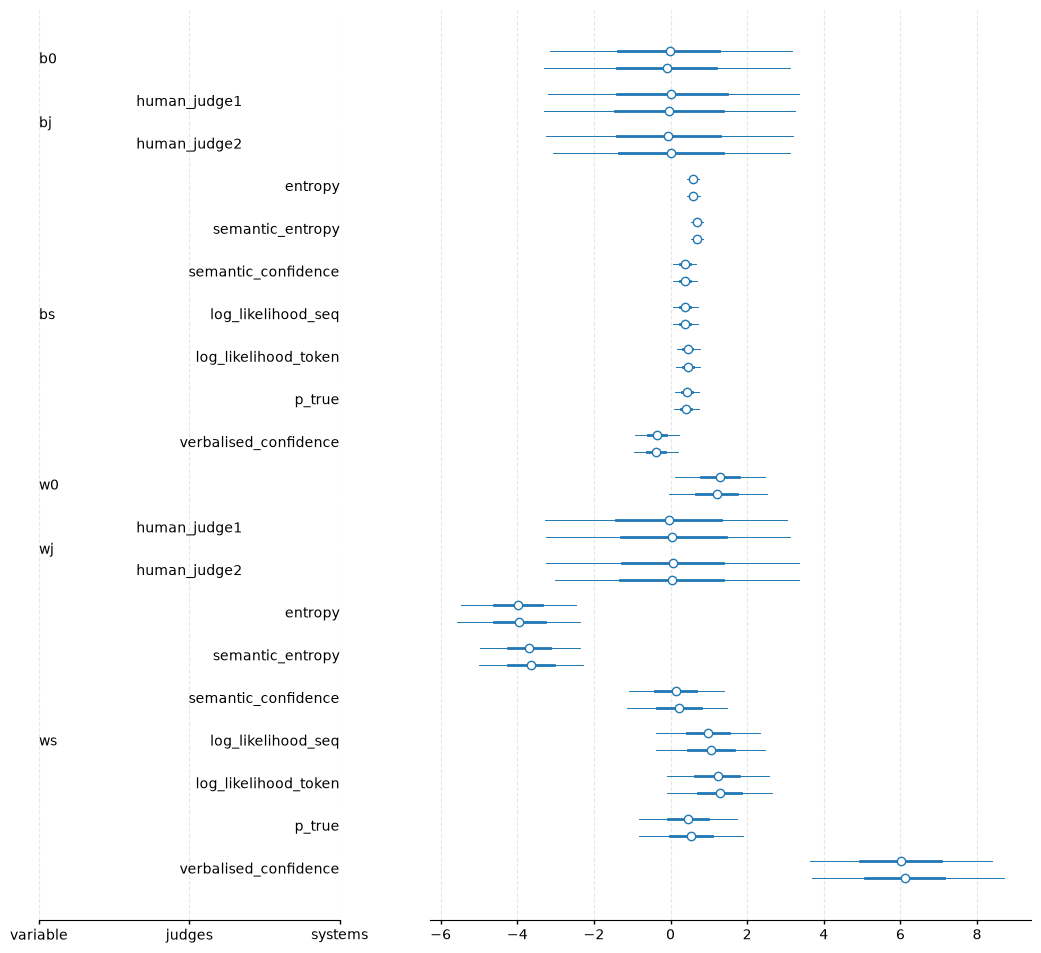

In [27]:
az.plot_forest(
    idata, 
    var_names=['b0', 'bj', 'bs', 'w0', 'wj', 'ws'],
)

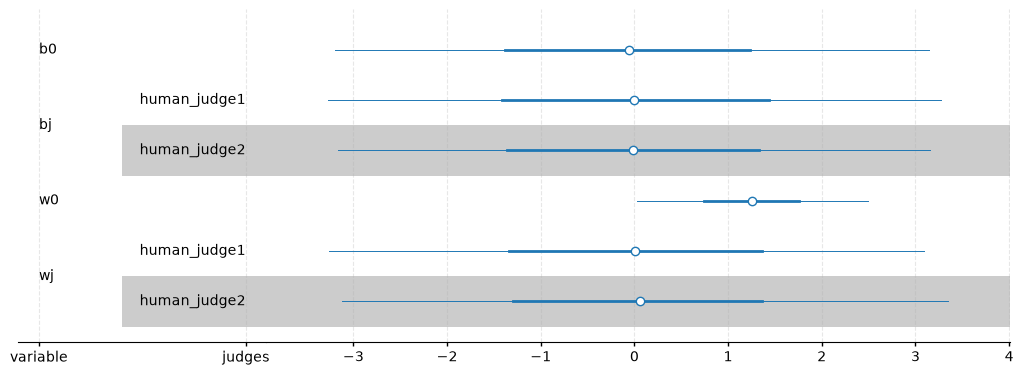

In [28]:
az.plot_forest(
    idata, 
    var_names=['b0', 'bj', 'w0', 'wj'],
    combined=True,
    shade_label='judges'
)

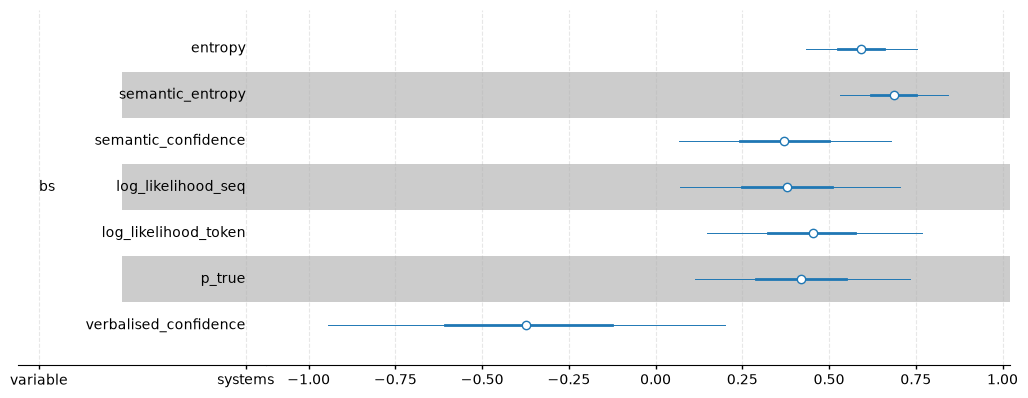

In [29]:
az.plot_forest(
    idata, 
    var_names=['bs'],
    combined=True,
    shade_label='systems'
)

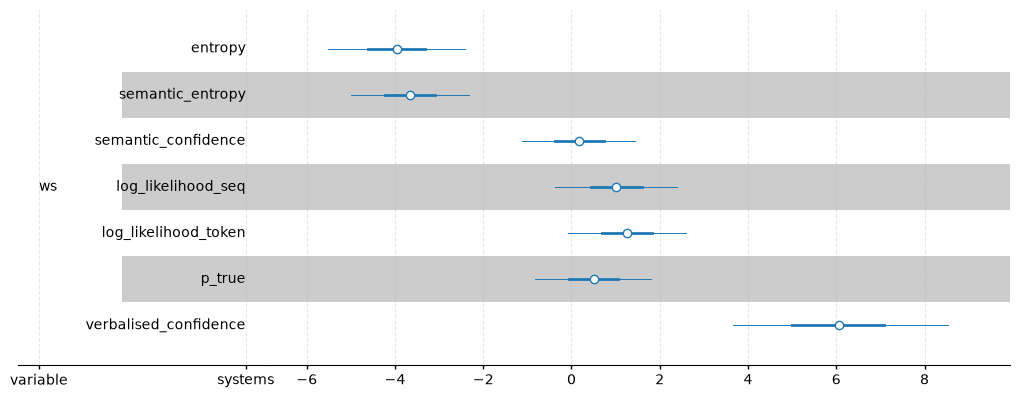

In [30]:
az.plot_forest(
    idata, 
    var_names=['ws'],
    combined=True,
    shade_label='systems'
)

In [31]:
posterior_samples = mcmc.get_samples(group_by_chain=False)
print("posterior samples shapes:")
for k, v in posterior_samples.items():
    print(k, v.shape)

posterior samples shapes:
b0 (4000,)
bj (4000, 2)
bs (4000, 7)
theta (4000, 1400)
w0 (4000,)
wj (4000, 2)
ws (4000, 7)
z (4000, 1400)
z0 (4000, 1400)
zj (4000, 1400)
zs (4000, 1400)


In [114]:
az.plot_dist?

Signature:
az.plot_dist(
    dt,
    *,
    var_names=None,
    filter_vars=None,
    group='posterior',
    coords=None,
    sample_dims=None,
    kind=None,
    point_estimate=None,
    ci_kind=None,
    ci_prob=None,
    plot_collection=None,
    backend=None,
    labeller=None,
    aes_by_visuals: collections.abc.Mapping[typing.Literal['dist', 'face', 'credible_interval', 'point_estimate', 'point_estimate_text', 'title', 'rug'], collections.abc.Sequence[str]] = None,
    visuals: collections.abc.Mapping[typing.Literal['dist', 'face', 'credible_interval', 'point_estimate', 'point_estimate_text', 'title', 'rug', 'remove_axis'], collections.abc.Mapping[str, typing.Any] | bool] = None,
    stats: collections.abc.Mapping[typing.Literal['dist', 'credible_interval', 'point_estimate'], collections.abc.Mapping[str, typing.Any] | xarray.core.dataset.Dataset] = None,
    **pc_kwargs,
)
Docstring:
Plot 1D marginal densities in the style of John K. Kruschke’s book [1]_.

Generate :term:`faceted

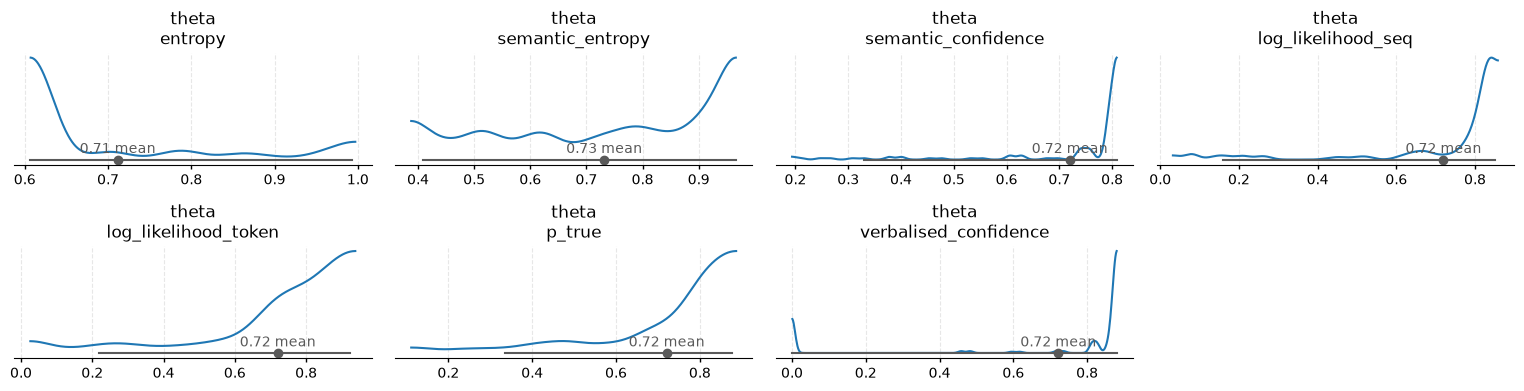

In [127]:
theta_dict = {'theta': []}
for sid in range(len(ds.sys2id)):
    theta_true = np.median(posterior_samples['theta'][:, np.logical_and(ds.S==sid, ds.Y)], 0)
    theta_false = np.median(posterior_samples['theta'][:, np.logical_and(ds.S==sid, ~ds.Y)], 0)
    theta_dict['theta'].append(np.concatenate([theta_true, theta_false], -1))
theta_data = az.from_dict(
    {
        'posterior': {'theta': np.stack(theta_dict['theta'], -1)[None, :, :]}
    },    
    dims={
        'theta': ['systems'],
    },
    coords={
        "systems": ds.sys2id,
        'items': ds.item2id
    }   
)
_ = az.plot_dist(
    theta_data,
    var_names=['theta'],
)  

_ = plt.tight_layout()
# _ = plt.tight_layout(h_pad=2, w_pad=2)

In [39]:
from numpyro.infer import Predictive
# Use Predictive to compute the 'effect_size' site for all posterior draws
predictive = Predictive(model, posterior_samples)
pred_samples = predictive(
    rng_key,
    y=None,
    x=ds.X,
    mask=np.ones_like(ds.X),
    judge=ds.J,
    system=ds.S,
    oracle=np.array([j_name.startswith('human_') for j_name in ds.judge2id.objects]),
    num_items=len(ds.item2id),
    num_judges=len(ds.judge2id),
    num_systems=len(ds.sys2id),    
)

In [42]:
for k, v in pred_samples.items():
    print(k, v.shape)    

obs (4000, 1400)
theta (4000, 1400)
z (4000, 1400)
z0 (4000, 1400)
zj (4000, 1400)
zs (4000, 1400)


(4000, 200)

In [59]:
import sklearn 
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, classification_report


pred_dict = {'acc': [], 'F1': []}
for sid in range(len(ds.sys2id)):

    predaccs = (pred_samples['obs'][:,ds.S==sid] == ds.Y[ds.S==sid]).mean(-1)
    predf1s = np.array([f1_score(ds.Y[ds.S==sid], y_) for y_ in pred_samples['obs'][:,ds.S==sid]])    
    pred_dict['acc'].append(predaccs)
    pred_dict['F1'].append(predf1s)
    # _ = plt.hist(predaccs, label=sname, alpha=0.5)
    # print(sname, predaccs.mean(), predaccs.std())
    # _ = plt.xlabel("Predictive accuracy")
# _ = plt.legend()

In [66]:
np.stack(pred_dict['acc'], -1).shape

(4000, 7)

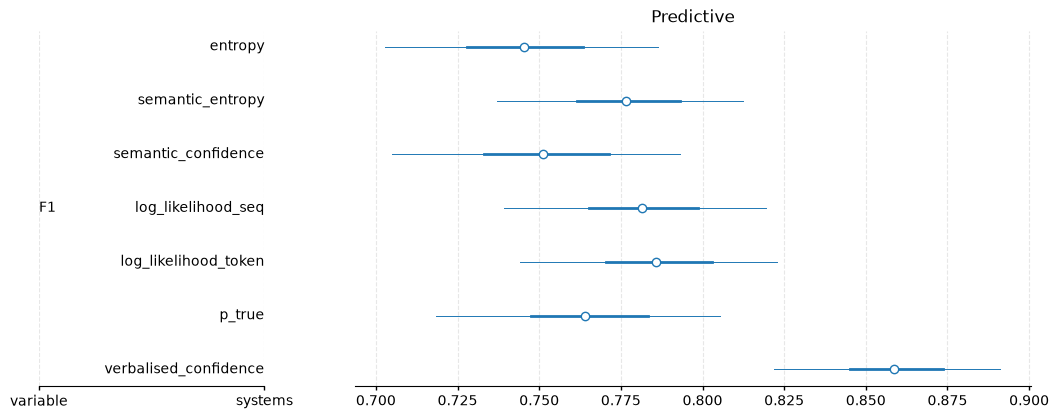

In [79]:
pred_data = az.from_dict(
    {
        'posterior': {'acc': np.stack(pred_dict['acc'], -1).reshape(2, 2000, -1), 'F1': np.stack(pred_dict['F1'], -1).reshape(2, 2000, -1)}
    },    
    dims={
        'acc': ['systems'],
        'F1': ['systems'],
    },
    coords={
        "systems": ds.sys2id,
    }   
)
_ = az.plot_forest(
    pred_data,
    var_names=['F1'],
    combined=True
)
_ = plt.title("Predictive")

In [32]:
(ds.S == 0).shape

(1400,)

In [33]:
posterior_samples['zs'][:, (ds.S == 0)].shape

(4000, 200)

The Oracle parameters

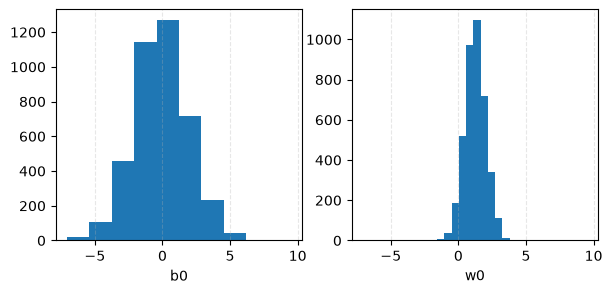

In [34]:
fig, axs = plt.subplots(1, 2, sharex=True, figsize=(7, 3))
_ = axs[0].hist(posterior_samples['b0'])
_ = axs[0].set_xlabel("b0")
_ = axs[1].hist(posterior_samples['w0'])
_ = axs[1].set_xlabel("w0")

The system parameters

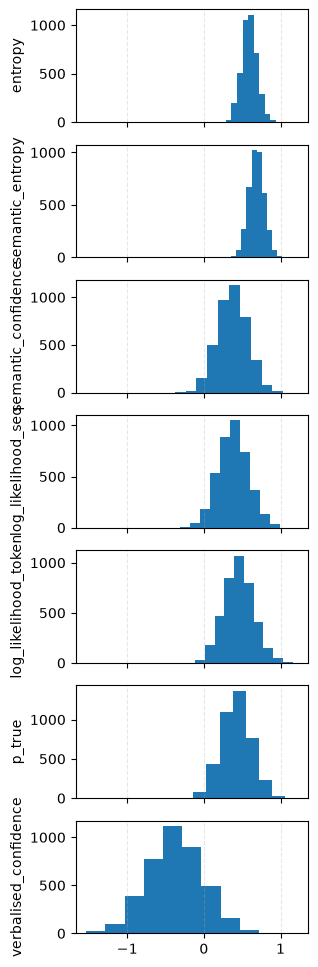

In [35]:
fig, axs = plt.subplots(len(ds.sys2id), 1, sharex=True, figsize=(3,12))

for s, system in enumerate(ds.sys2id.objects):
    axs[s].hist(posterior_samples['bs'][:,s])
    axs[s].set_ylabel(system)

The slopes will capture a predictive association between the confidence score and the judge. A positive slope means that the confidence score is a useful predictor of the judgments.

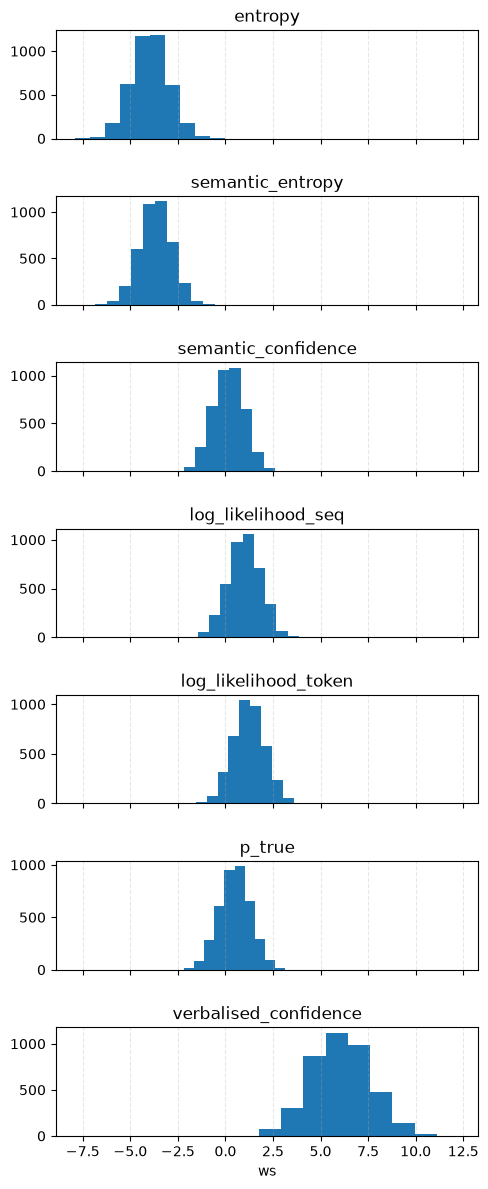

In [36]:
fig, axs = plt.subplots(len(ds.sys2id), 1, sharex=True, figsize=(5,12))
for s, system in enumerate(ds.sys2id.objects):
    axs[s].hist(posterior_samples['ws'][:,s])
    axs[s].set_title(system)
    axs[-1].set_xlabel("ws")

fig.tight_layout(h_pad=2, w_pad=2)

The linear predictors

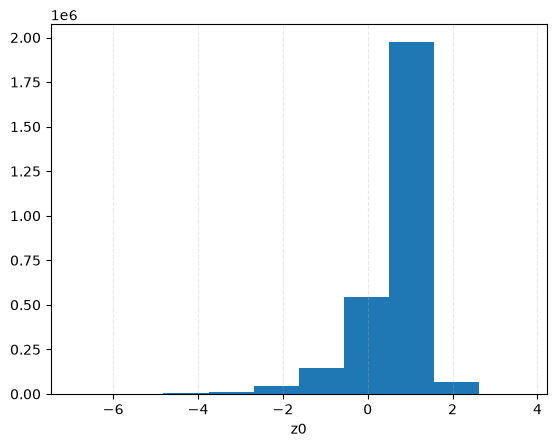

In [37]:
_ = plt.hist(posterior_samples['zj'][:, (ds.J == 0)].flatten())
_ = plt.xlabel("z0")

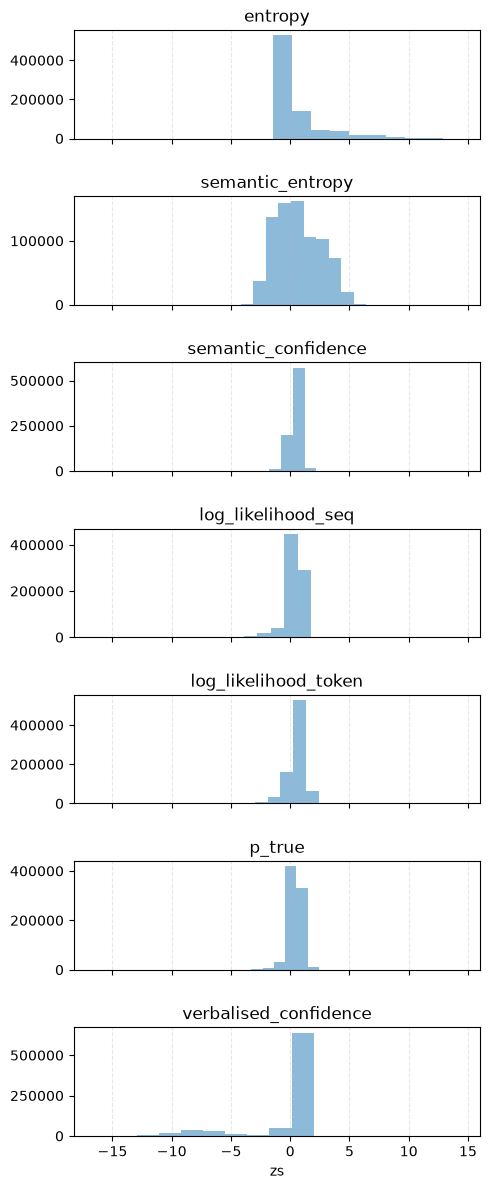

In [38]:
fig, axs = plt.subplots(len(ds.sys2id), 1, sharex=True, figsize=(5,12))
z0 = posterior_samples['zj'][:, (ds.J == 0)].flatten()
for s, system in enumerate(ds.sys2id.objects):    
    zs = posterior_samples['zs'][:, (ds.S == s)].flatten()
    axs[s].hist(zs, alpha=0.5, label='system')
    axs[s].set_title(system)
    axs[-1].set_xlabel("zs")

fig.tight_layout(h_pad=2, w_pad=2)

# Store predictions

In [ ]:
!mkdir -p inferences

We can use mean or median, as these are distributions over (0, 1) the median makes more sense

In [ ]:
posterior_confidence = np.median(posterior_samples['theta'], 0)

In [ ]:
# Store the confidences in a json
confs = []
unique = set()
for i, s, x, p in zip(ds.I, ds.S, ds.X, posterior_confidence):
    confs.append({'item': ds.item2id[int(i)], 'system': ds.sys2id[int(s)], 'score': x, 'posterior_confidence': float(p)})
    unique.add(f"{i}/{s}")
print(len(confs), len(unique))
with open(f"inferences/{experiment}.confidences.json", 'w') as fp:
    json.dump(confs, fp)

Use the following to save all sampled confidences

In [ ]:
save_sampled_confs = False

if save_sampled_confs:
    # Store the confidences in a json
    sampled_confs = []
    for n, (i, s, x) in enumerate(zip(ds.I, ds.S, ds.X)):
        sampled_confs.append({'item': ds.item2id[int(i)], 'system': ds.sys2id[int(s)], 'score': x, 'sampled_confidences': posterior_samples['theta'][:,n].tolist()})
    with open(f"inferences/{experiment}.confidence-samples.json", 'w') as fp:
        json.dump(sampled_confs, fp)